# Stage-1 HPO Winner Analysis

Quick analysis notebook for Stage-1 HPO runs (QBC or Marker).
It loads `matrix.tsv` + per-run `qbc/history.jsonl`, summarizes metrics, and ranks candidate configs.


In [4]:
from __future__ import annotations

import csv
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 140)
pd.set_option('display.max_columns', 200)


In [14]:
# --- Configure ---
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists() or (candidate / 'outputs').exists():
            return candidate
    raise FileNotFoundError(f'Could not locate repo root from: {start}')

REPO_ROOT = find_repo_root(Path.cwd())
METHOD = 'marker_directed'  # 'qbc_deep_ensemble' | 'marker_directed'
STAGE = 'stage1_policy_search'
HPO_ID = None  # set explicit folder name if needed, else latest folder is used

HPO_BASE = REPO_ROOT / 'outputs' / 'hpo' / METHOD / STAGE
if not HPO_BASE.exists():
    raise FileNotFoundError(f'HPO path not found: {HPO_BASE}')

if HPO_ID is None:
    candidates = sorted([p for p in HPO_BASE.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise RuntimeError(f'No HPO runs found in: {HPO_BASE}')
    HPO_RUN = candidates[-1]
else:
    HPO_RUN = HPO_BASE / HPO_ID

MATRIX_PATH = HPO_RUN / 'matrix.tsv'
if not MATRIX_PATH.exists():
    raise FileNotFoundError(f'Matrix not found: {MATRIX_PATH}')

print('REPO_ROOT:', REPO_ROOT)
print('HPO_RUN:', HPO_RUN)
print('MATRIX_PATH:', MATRIX_PATH)


REPO_ROOT: /zhome/14/b/214266/Repos/ml-surrogates-for-power-systems
HPO_RUN: /zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/hpo/marker_directed/stage1_policy_search/marker_directed_policy_search_20260301_160048
MATRIX_PATH: /zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/hpo/marker_directed/stage1_policy_search/marker_directed_policy_search_20260301_160048/matrix.tsv


In [15]:
def _parse_override_blob(blob: str) -> dict[str, str]:
    out = {}
    text = (blob or '').strip()
    if not text:
        return out
    for part in text.split(';;'):
        if '=' not in part:
            continue
        k, v = part.split('=', 1)
        out[k] = v
    return out

def _load_last_history_row(history_path: Path) -> dict:
    if not history_path.exists():
        return {}
    last = None
    with history_path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            last = json.loads(line)
    return last or {}

def _as_float_or_nan(x):
    try:
        if x is None:
            return np.nan
        return float(x)
    except Exception:
        return np.nan


In [16]:
matrix = pd.read_csv(MATRIX_PATH, sep='\t')
rows = []

for _, r in matrix.iterrows():
    run_root = Path(r['run_root'])
    status_path = run_root / 'hpo_status.json'
    manifest_path = run_root / 'run_manifest.json'
    history_path = run_root / 'qbc' / 'history.jsonl'

    status = {}
    if status_path.exists():
        status = json.loads(status_path.read_text(encoding='utf-8'))

    manifest = {}
    if manifest_path.exists():
        manifest = json.loads(manifest_path.read_text(encoding='utf-8'))

    last_hist = _load_last_history_row(history_path)

    stage1_overrides = _parse_override_blob(r.get('stage1_overrides', ''))

    rows.append({
        'cfg_id': r['cfg_id'],
        'row_idx': int(r['row_idx']),
        'seed': r['seed'],
        'budget': r['budget'],
        'run_root': str(run_root),
        'status_code': status.get('return_code', np.nan),
        'status_ok': (status.get('return_code', 1) == 0),
        'final_round_idx': last_hist.get('round_idx', np.nan),
        'final_train_size': last_hist.get('train_size', np.nan),
        'final_eval_rmse': _as_float_or_nan(last_hist.get('eval_rmse')),
        'final_eval_mse': _as_float_or_nan(last_hist.get('eval_mse')),
        'final_selected_mean_score': _as_float_or_nan(last_hist.get('selected_mean_score')),
        'final_mean_score': _as_float_or_nan(last_hist.get('mean_score')),
        'stage1_overrides': r.get('stage1_overrides', ''),
        'config_signature': r.get('stage1_overrides', ''),
        **{f'ov::{k}': v for k, v in stage1_overrides.items()},
    })

df = pd.DataFrame(rows)
print('rows:', len(df))
print('successful rows:', int(df['status_ok'].sum()))
df.head(3)


rows: 144
successful rows: 144


,cfg_id,row_idx,seed,budget,run_root,status_code,status_ok,final_round_idx,final_train_size,final_eval_rmse,final_eval_mse,final_selected_mean_score,final_mean_score,stage1_overrides,config_signature,ov::active.candidate_method,ov::active.log_every,ov::active.marker.greedy_score_weight,ov::active.marker.include_anchor_state_markers,ov::active.marker.k_density,ov::active.marker.pca_explained_variance,ov::active.marker.preselect_factor,ov::active.marker.settling_fraction,ov::active.marker.weights.diversity,ov::active.marker.weights.sparsity,ov::qbc_K,ov::qbc_P,ov::qbc_T,ov::qbc_enable_logging,ov::qbc_n0
0,cfg_00000_e39ef96d9e,0,s01,b1024,/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/hpo/marker_directed/stage1_policy_search/marker_directed_policy_search_...,0,True,14,960,NaN,NaN,0.135668,0.075362,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.7;;active.marker.include_anchor_state_markers=true;...,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.7;;active.marker.include_anchor_state_markers=true;...,lhs,5,0.7,true,10,0.9,3,0.05,0.4,0.4,64,2048,15,true,64
1,cfg_00001_042bcd2e25,1,s01,b1024,/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/hpo/marker_directed/stage1_policy_search/marker_directed_policy_search_...,0,True,14,960,NaN,NaN,0.143994,0.080884,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.7;;active.marker.include_anchor_state_markers=true;...,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.7;;active.marker.include_anchor_state_markers=true;...,lhs,5,0.7,true,10,0.9,3,0.05,0.6,0.4,64,2048,15,true,64
2,cfg_00002_ed88606e48,2,s01,b1024,/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/hpo/marker_directed/stage1_policy_search/marker_directed_policy_search_...,0,True,14,960,NaN,NaN,0.149386,0.083024,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.7;;active.marker.include_anchor_state_markers=true;...,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.7;;active.marker.include_anchor_state_markers=true;...,lhs,5,0.7,true,10,0.9,3,0.05,0.8,0.4,64,2048,15,true,64


In [17]:
# Failures / incomplete rows
display(df.loc[~df['status_ok'], ['cfg_id','seed','budget','status_code','run_root']].head(20))


,cfg_id,seed,budget,status_code,run_root


In [18]:
# Decide ranking metric
metric_candidates = ['final_eval_rmse', 'final_eval_mse', 'final_selected_mean_score']
available = [m for m in metric_candidates if df[m].notna().any()]
print('Available ranking metrics:', available)

if 'final_eval_rmse' in available:
    RANK_METRIC = 'final_eval_rmse'
    ASCENDING = True
elif 'final_eval_mse' in available:
    RANK_METRIC = 'final_eval_mse'
    ASCENDING = True
else:
    RANK_METRIC = 'final_selected_mean_score'
    ASCENDING = False

print('Using ranking metric:', RANK_METRIC, '| ascending:', ASCENDING)


Available ranking metrics: ['final_selected_mean_score']
Using ranking metric: final_selected_mean_score | ascending: False


In [19]:
# Aggregate by configuration (across seeds)
agg = (
    df[df['status_ok']]
    .groupby('config_signature', as_index=False)
    .agg(
        n_runs=('cfg_id', 'count'),
        n_seeds=('seed', 'nunique'),
        mean_metric=(RANK_METRIC, 'mean'),
        std_metric=(RANK_METRIC, 'std'),
        min_metric=(RANK_METRIC, 'min'),
        max_metric=(RANK_METRIC, 'max'),
    )
    .sort_values(['mean_metric','std_metric'], ascending=[ASCENDING, True])
    .reset_index(drop=True)
)

top = agg.head(10)
display(top)

WINNER_SIGNATURE = top.iloc[0]['config_signature'] if len(top) else None
print('Winner signature:', WINNER_SIGNATURE)


,config_signature,n_runs,n_seeds,mean_metric,std_metric,min_metric,max_metric
0,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,3,3,0.478517,0.272962,0.163900,0.652275
1,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,3,3,0.472817,0.286821,0.143018,0.664001
2,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,3,3,0.469109,0.257000,0.173235,0.636870
3,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,3,3,0.455977,0.262584,0.153868,0.629353
4,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,3,3,0.450206,0.247121,0.164887,0.596560
5,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,3,3,0.448574,0.255882,0.153576,0.610483
6,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.7;;active.marker.include_anchor_state_markers=true;...,3,3,0.448364,0.260169,0.149386,0.623286
7,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.7;;active.marker.include_anchor_state_markers=true;...,3,3,0.443495,0.257132,0.147570,0.612386
8,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,3,3,0.443418,0.248175,0.157981,0.608159
9,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,3,3,0.434573,0.248567,0.147570,0.580841


Winner signature: active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;;active.marker.k_density=20;;active.marker.pca_explained_variance=0.9;;active.marker.preselect_factor=3;;active.marker.settling_fraction=0.05;;active.marker.weights.diversity=0.8;;active.marker.weights.sparsity=0.4;;qbc_K=64;;qbc_P=2048;;qbc_T=15;;qbc_enable_logging=true;;qbc_n0=64


In [20]:
# Seed-level consistency for top configs
top_signatures = agg.head(5)['config_signature'].tolist()
seed_view = (
    df[df['config_signature'].isin(top_signatures)][['cfg_id','seed','budget','config_signature',RANK_METRIC,'status_ok']]
    .sort_values(['config_signature','seed'])
)
display(seed_view)


,cfg_id,seed,budget,config_signature,final_selected_mean_score,status_ok
3,cfg_00003_502db627bc,s01,b1024,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,0.153868,True
51,cfg_00051_eaadf75f00,s02,b1024,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,0.584709,True
99,cfg_00099_8f3cea54ce,s03,b1024,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,0.629353,True
5,cfg_00005_ef89ca8a58,s01,b1024,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,0.173235,True
53,cfg_00053_73f32fe453,s02,b1024,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,0.636870,True
101,cfg_00101_6be473c89d,s03,b1024,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,0.597222,True
11,cfg_00011_d9d7b7503b,s01,b1024,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,0.164887,True
59,cfg_00059_a8b7367e40,s02,b1024,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,0.589171,True
107,cfg_00107_388820a2c4,s03,b1024,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,0.596560,True
15,cfg_00015_356abe1701,s01,b1024,active.candidate_method=lhs;;active.log_every=5;;active.marker.greedy_score_weight=0.9;;active.marker.include_anchor_state_markers=true;...,0.143018,True


/tmp/ipykernel_325387/2419059694.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f'cfg{i+1}' for i in range(len(order))], showmeans=True)


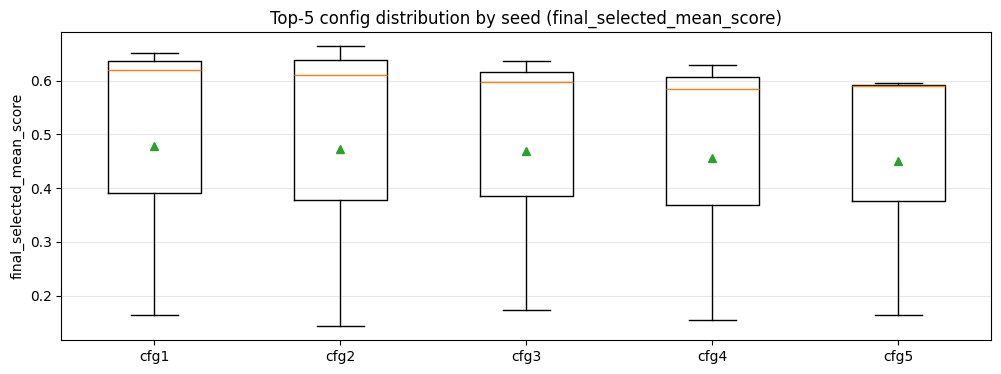

In [21]:
# Quick plot for top-5 configs
plot_df = df[df['config_signature'].isin(top_signatures) & df[RANK_METRIC].notna()].copy()
if len(plot_df):
    fig, ax = plt.subplots(figsize=(12, 4))
    order = list(agg.head(5)['config_signature'])
    data = [plot_df.loc[plot_df['config_signature'] == s, RANK_METRIC].values for s in order]
    ax.boxplot(data, labels=[f'cfg{i+1}' for i in range(len(order))], showmeans=True)
    ax.set_title(f'Top-5 config distribution by seed ({RANK_METRIC})')
    ax.set_ylabel(RANK_METRIC)
    ax.grid(True, axis='y', alpha=0.3)
    plt.show()
else:
    print('No numeric metric values available for plotting.')


In [22]:
# Export winner tables
summary_dir = HPO_RUN / 'summary'
summary_dir.mkdir(parents=True, exist_ok=True)

all_rows_path = summary_dir / 'stage1_rows_summary.csv'
agg_path = summary_dir / 'stage1_config_ranking.csv'
winner_path = summary_dir / 'stage1_winner.csv'

df.to_csv(all_rows_path, index=False)
agg.to_csv(agg_path, index=False)
if len(agg):
    agg.head(1).to_csv(winner_path, index=False)

print('Wrote:', all_rows_path)
print('Wrote:', agg_path)
if len(agg):
    print('Wrote:', winner_path)


Wrote: /zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/hpo/marker_directed/stage1_policy_search/marker_directed_policy_search_20260301_160048/summary/stage1_rows_summary.csv
Wrote: /zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/hpo/marker_directed/stage1_policy_search/marker_directed_policy_search_20260301_160048/summary/stage1_config_ranking.csv
Wrote: /zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/hpo/marker_directed/stage1_policy_search/marker_directed_policy_search_20260301_160048/summary/stage1_winner.csv
